In [1]:
import pandas as pd

# UCI Machine Learning Repository se direct Heart Disease dataset ka link
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"

# Columns ke asli naam jo medical science ke mutabiq hain
columns = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 
    'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal', 'target'
]

# Data load karein (missing values isme '?' ki shakl me hain)
df_heart = pd.read_csv(url, names=columns, na_values="?")

# Apne folder me local CSV save kar lein
df_heart.to_csv('heart_disease_real.csv', index=False)
print(f"Real-world Dataset downloaded successfully! Shape: {df_heart.shape}")

Real-world Dataset downloaded successfully! Shape: (303, 14)


In [2]:
df_heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


In [3]:
# 1. Pehli 5 rows dekhein
print(df_heart.head())

# 2. Check karein ke real dataset me missing values kitni hain
print("\nMissing Values:")
print(df_heart.isnull().sum())


    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  

Missing Values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64


In [4]:
df_heart.shape

(303, 14)

In [5]:
# 1. Missing values ko Mode (sab se common value) se fill karein
df_heart['ca'] = df_heart['ca'].fillna(df_heart['ca'].mode()[0])
df_heart['thal'] = df_heart['thal'].fillna(df_heart['thal'].mode()[0])

# 2. Target column ko binary (0 aur 1) me convert karein
# Agar target 0 se bada hai to 1 kar do, warna 0 rehne do
df_heart['target'] = (df_heart['target'] > 0).astype(int)

# 3. Verify karein ke target columns theek ho gaye aur missing values khatam huin
print("Missing values check after cleaning:")
print(df_heart.isnull().sum().sum())
print("\nTarget values count:")
print(df_heart['target'].value_counts())

Missing values check after cleaning:
0

Target values count:
target
0    164
1    139
Name: count, dtype: int64


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Features (X) aur Target (y) ko alag karein
X = df_heart.drop(columns=['target'])
y = df_heart['target']

# 2. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 3. Scaling (Sirf KNN ke liye zaroori taake distances automatic scale ho jayein)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train-Test Split aur Scaling complete!")
print(f"X_train shape: {X_train_scaled.shape}, X_test shape: {X_test_scaled.shape}")

Train-Test Split aur Scaling complete!
X_train shape: (242, 13), X_test shape: (61, 13)


In [9]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report

# 1. KNN Classifier initialize karein (K=5 ke sath shuru karte hain)
knn = KNeighborsClassifier(n_neighbors=9)

# 2. Model ko scaled training data par train karein
knn.fit(X_train_scaled, y_train)

# 3. Test data par predictions nikalein
y_pred = knn.predict(X_test_scaled)

# 4. Accuracy check karein
accuracy = accuracy_score(y_test, y_pred)
print(f"KNN Model Accuracy: {accuracy * 100:.2f}%\n")
print("Detailed Classification Report:")
print(classification_report(y_test, y_pred))

KNN Model Accuracy: 90.16%

Detailed Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        33
           1       0.82      1.00      0.90        28

    accuracy                           0.90        61
   macro avg       0.91      0.91      0.90        61
weighted avg       0.92      0.90      0.90        61



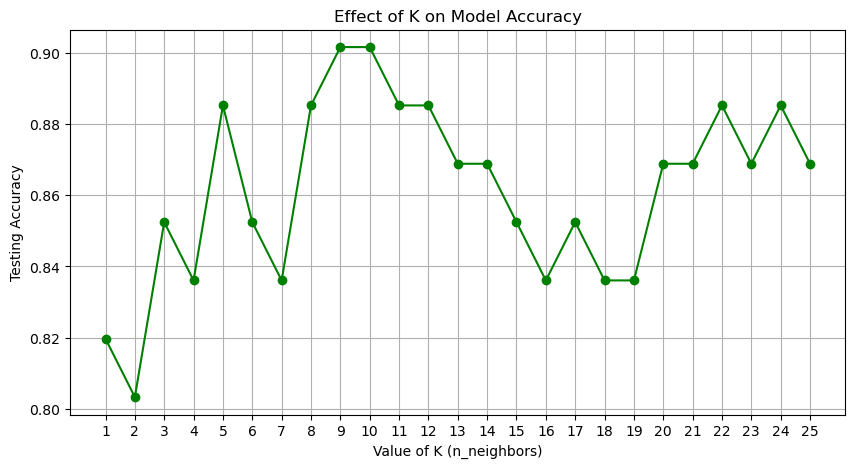

Sab se behtar accuracy dene wali K ki value hai: 9 (Accuracy: 90.16%)


In [10]:
import matplotlib.pyplot as plt

scores = []
# 1 se 25 tak different K values check karein
for k in range(1, 26):
    knn_test = KNeighborsClassifier(n_neighbors=k)
    knn_test.fit(X_train_scaled, y_train)
    y_pred_test = knn_test.predict(X_test_scaled)
    scores.append(accuracy_score(y_test, y_pred_test))

# Graph plot karke dekhein ke kahan peak aati hai
plt.figure(figsize=(10, 5))
plt.plot(range(1, 26), scores, marker='o', linestyle='-', color='g')
plt.title('Effect of K on Model Accuracy')
plt.xlabel('Value of K (n_neighbors)')
plt.ylabel('Testing Accuracy')
plt.xticks(range(1, 26))
plt.grid()
plt.show()

# Best K nikalwein
best_k = range(1, 26)[scores.index(max(scores))]
print(f"Sab se behtar accuracy dene wali K ki value hai: {best_k} (Accuracy: {max(scores)*100:.2f}%)")

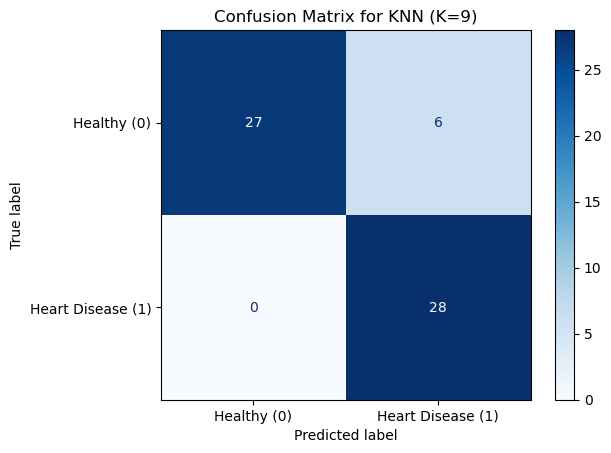

In [11]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# Confusion Matrix calculate karein
cm = confusion_matrix(y_test, y_pred)

# Visualize karein
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Healthy (0)', 'Heart Disease (1)'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix for KNN (K={best_k})')
plt.show()